# look at training progress

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import os

In [16]:
folder = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_06__17_14_44/"
names = [name[:-4] for name in os.listdir(folder) if name.endswith(".npy")]
files = [f"{folder}{name}.npy" for name in names]
print(names)
data = {name: np.load(file) for name, file in zip(names, files)}
pretty  = {"loss":"Loss", "grad_norm": "Gradient norm", "ema_decay": "EMA decay"}

['grad_norm', 'n_events', 'ema_decay', 'loss', 'epoch_number', 'n_updates', 'time']


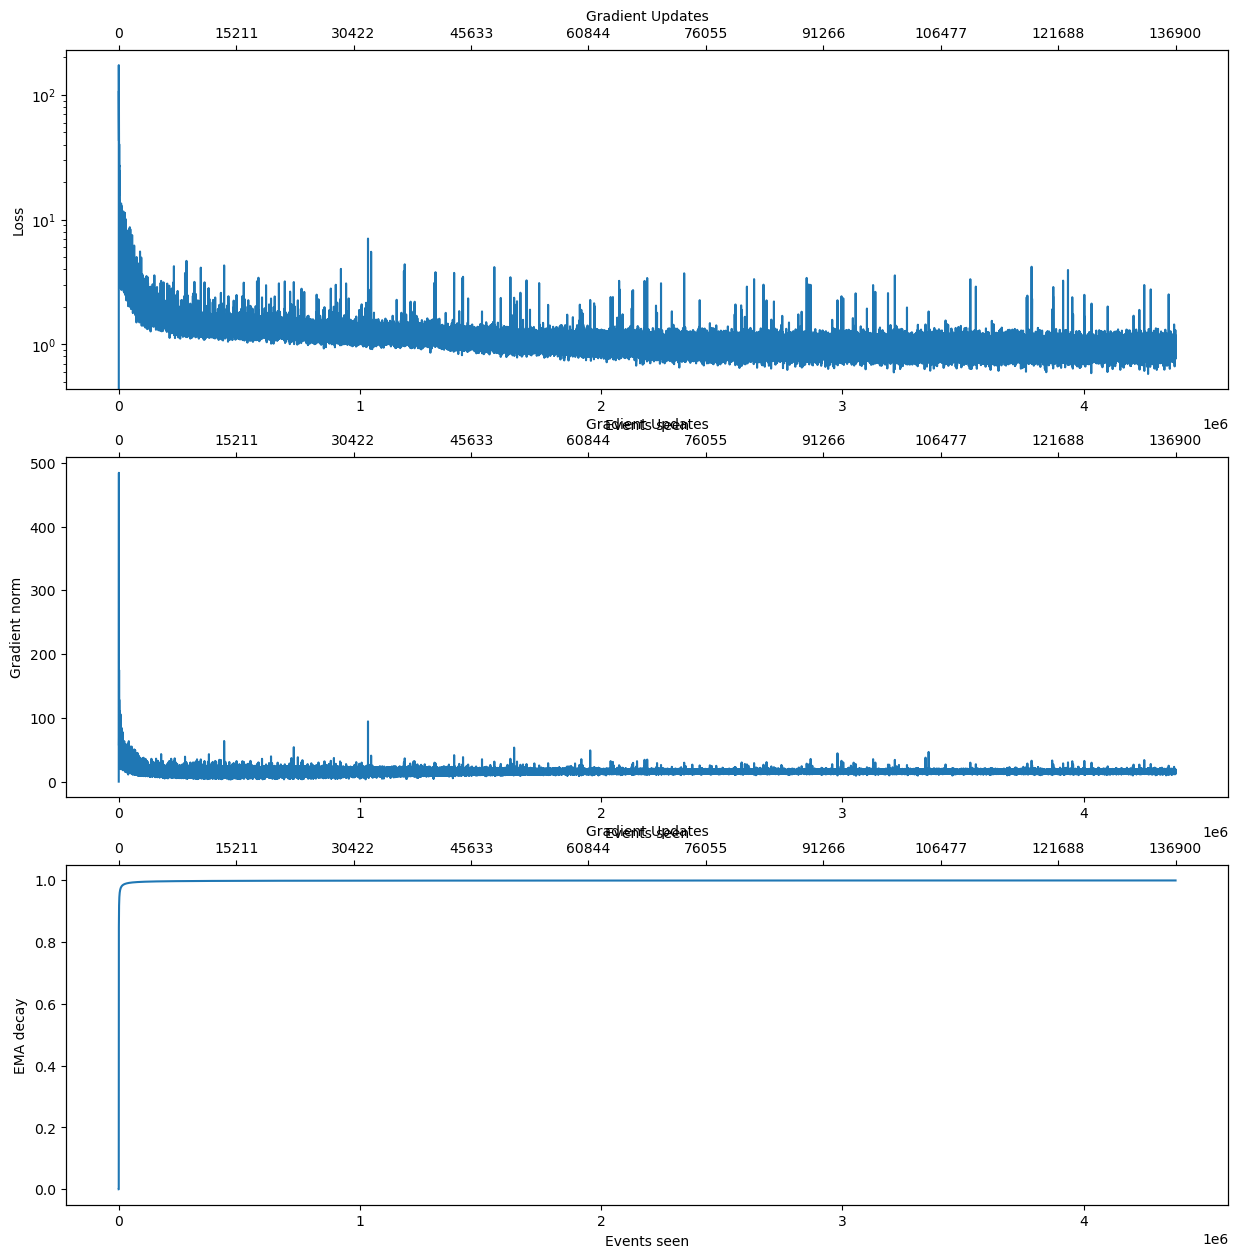

In [19]:
fig, axarr = plt.subplots(3, 1, figsize=(15, 15))
x_name = 'n_events'
for i, (y_name, y_label) in enumerate(pretty.items()):
    ax = axarr[i]

    ax.plot(data[x_name], data[y_name])
    if y_name in ["loss", "gradient_norm"]:
        ax.semilogy()
    ax.set_xlabel("Events seen")
    ax.set_ylabel(y_label)
    
    n_values = len(data[x_name])
    n_ticks = 10
    value_idxs = np.linspace(0, n_values-1, n_ticks).astype(int)
    positions = [data[x_name][idx] for idx in value_idxs]
    labels = [data['n_updates'][idx] for idx in value_idxs]
    ax2 = ax.twiny()          # <- this was missing
    ax2.set_xlim(ax.get_xlim())                   # share the bottom's coordinates
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel("Gradient Updates")

